In [2]:
from oneargopy.OneArgo import Argo
from argopy import DataFetcher as ArgoDataFetcher
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from argopy import ArgoFloat
import gsw
import numpy as np

In [4]:
argo = Argo('argo_config.json')

Starting initialize process...
Your current download settings are: 
[DownloadSettings] -> 
Base Directory: ., 
Subdirectories: ['Index', 'Meta', 'Tech', 'Traj', 'Profiles'], 
Index Files: ['ar_index_global_traj.txt', 'ar_index_global_tech.txt', 'ar_index_global_meta.txt', 'ar_index_global_prof.txt', 'argo_synthetic-profile_index.txt'], 
Verbose Setting: True, 
Max Attempts: 5, 
Keep Index In Memory: True, 
Float Type: bgc

Your current source settings are: 
[Source Settings] -> 
Hosts: ['https://data-argo.ifremer.fr/', 'https://usgodae.org/ftp/outgoing/argo/'], 
Available Variables: None, 
Data Assimilation Centers: None

Checking for subdirectories...
The Index directory already exists
The Meta directory already exists
The Tech directory already exists
The Traj directory already exists
The Profiles directory already exists

Updating ar_index_global_traj.txt...
Unzipping ar_index_global_traj.txt.gz...
Success!
Updating ar_index_global_tech.txt...
Unzipping ar_index_global_tech.txt.gz..

/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/oneargopy/OneArgo.py:611: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  values='data_type').fillna(0).infer_objects(copy=False).astype('int8')


Filling in source settings information...
Marking Parameters with their data mode...
Filling in source settings information...
Marking bgc floats in prof_index dataframe...
Creating float_stats dataframe...

20054 floats with 3306938 profiles found.
2795 BGC floats with 383248 profiles found.
Initialization is finished




In [46]:
# depth profiles (conservative temperature, absolute salinity, potential density) of six cycles through the year (January, March, May, July, September, November)
# add mixed layer depth 

In [6]:
profile = argo.select_profiles(floats=6901004)
df = argo.load_float_data(profile, variables=['DOXY','TEMP','PSAL','CHLA', 'BBP700','NITRATE','PH_IN_SITU_TOTAL'])
df.to_csv('/Users/lilah/Documents/IBIS_Project/profile_6901004.csv', index='False') # add read csv

Starting select_profiles...
Validating parameters...
Validating longitude and latitude limits...
Validating start and end dates...
Validating 'type' keyword argument...
Preparing float data for filtering...
Validating passed floats...
Filtering through 1 floats
There are 351 profiles associated with these floats

Applying outside=None constraints...
1 floats selected
351 profiles selected according to time and space constraints
Floats Selected: dict_keys([6901004])

Validating passed floats...
Validating passed 'variables'...
6901004_Sprof.nc does not need to be updated yet.
Loading float data...
Loading Float data from float 6901004 with 351 profiles...


/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/oneargopy/OneArgo.py:769: UserWarning: no explicit representation of timezones available for np.datetime64
  self.start_date = np.datetime64(self.start_date)
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/oneargopy/OneArgo.py:770: UserWarning: no explicit representation of timezones available for np.datetime64
  self.end_date = np.datetime64(self.end_date)
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/oneargopy/OneArgo.py:1074: UserWarning: no explicit representation of timezones available for np.datetime64
  beginning_of_full_range = np.datetime64(datetime(1995, 1, 1, tzinfo=timezone.utc))
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/oneargopy/OneArgo.py:1075: UserWarning: no explicit representation of timezones available for np.datetime64
  end_of_full_range = np.datetime64(datetime.now(timezone.utc))
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/oneargopy/One

Dropping rows where no measurements were taken for 6901004...


In [7]:
#convert to datetime
df['DATE'] = pd.to_datetime(df['DATE'],format = 'mixed')
#subset data with good QC only
qc_flags = [1,2,8]
df_clean = df[df['CHLA_ADJUSTED_QC'].isin(qc_flags) & df['PRES_ADJUSTED_QC'].isin(qc_flags) & df['TEMP_ADJUSTED_QC'].isin(qc_flags) & df['PSAL_ADJUSTED_QC'].isin(qc_flags)]


In [49]:
# Specify the cycles you want to include in a list: January (2017-01-22, cycle 230)
target_cycles_1 = [230]

# Create a mask using isin()
mask_multiple_1 = df['CYCLE_NUMBER'].isin(target_cycles_1)

# Apply the mask
multiple_cycles_subset_1 = df[mask_multiple_1]

In [52]:
# Specify the cycles you want to include in a list: March (2017-03-05, cycle 250)
target_cycles_2 = [250]

# Create a mask using isin()
mask_multiple_2 = df['CYCLE_NUMBER'].isin(target_cycles_2)

# Apply the mask
multiple_cycles_subset_2 = df[mask_multiple_2]

In [53]:
# Specify the cycles you want to include in a list: May (2017-05-09, cycle 265)
target_cycles_3 = [265]

# Create a mask using isin()
mask_multiple_3 = df['CYCLE_NUMBER'].isin(target_cycles_3)

# Apply the mask
multiple_cycles_subset_3 = df[mask_multiple_3]

In [56]:
# Specify the cycles you want to include in a list: July (2017-07-23, cycle 280)
target_cycles_4 = [280]

# Create a mask using isin()
mask_multiple_4 = df['CYCLE_NUMBER'].isin(target_cycles_4)

# Apply the mask
multiple_cycles_subset_4 = df[mask_multiple_4]

In [58]:
# Specify the cycles you want to include in a list: September (2017-09-07, cycle 290)
target_cycles_5 = [290]

# Create a mask using isin()
mask_multiple_5 = df['CYCLE_NUMBER'].isin(target_cycles_5)

# Apply the mask
multiple_cycles_subset_5 = df[mask_multiple_5]

In [60]:
# Specify the cycles you want to include in a list: November (2017-11-13, cycle 320)
target_cycles_6 = [320]

# Create a mask using isin()
mask_multiple_6 = df['CYCLE_NUMBER'].isin(target_cycles_6)

# Apply the mask
multiple_cycles_subset_6 = df[mask_multiple_6]

In [61]:
multiple_cycles_subset_6['DATE']

391764   2017-11-13 23:48:00
391765   2017-11-13 23:48:00
391766   2017-11-13 23:48:00
391767   2017-11-13 23:48:00
391768   2017-11-13 23:48:00
                 ...        
393133   2017-11-13 23:48:00
393134   2017-11-13 23:48:00
393135   2017-11-13 23:48:00
393136   2017-11-13 23:48:00
393137   2017-11-13 23:48:00
Name: DATE, Length: 1374, dtype: datetime64[ns]

In [63]:
# calculating absolute salinity
abs_sal_1 = gsw.conversions.SA_from_SP(multiple_cycles_subset_1['PSAL'], multiple_cycles_subset_1['PRES'], multiple_cycles_subset_1['LONGITUDE'], multiple_cycles_subset_1['LATITUDE'])
# calculating conservative temperature
cons_temp_1 = gsw.CT_from_t(abs_sal_1, multiple_cycles_subset_1['TEMP'], multiple_cycles_subset_1['PRES'])
sigma0_1 = gsw.sigma0(abs_sal_1, cons_temp_1)
#calculating potential density
p_density_1 = sigma0_1 + 1000
# calculating depths from pressure for each cycle/
depth_1 = gsw.conversions.z_from_p(multiple_cycles_subset_1['PRES_ADJUSTED'], multiple_cycles_subset_1['LATITUDE'])
# making depths positive (convention of y axis being inverted and values being positive)
depth_1_pos = abs(depth_1)

In [64]:
# calculating absolute salinity
abs_sal_2 = gsw.conversions.SA_from_SP(multiple_cycles_subset_2['PSAL'], multiple_cycles_subset_2['PRES'], multiple_cycles_subset_2['LONGITUDE'], multiple_cycles_subset_2['LATITUDE'])
# calculating conservative temperature
cons_temp_2 = gsw.CT_from_t(abs_sal_2, multiple_cycles_subset_2['TEMP'], multiple_cycles_subset_2['PRES'])
sigma0_2 = gsw.sigma0(abs_sal_2, cons_temp_2)
#calculating potential density
p_density_2 = sigma0_2 + 1000
# calculating depths from pressure for each cycle/
depth_2 = gsw.conversions.z_from_p(multiple_cycles_subset_2['PRES_ADJUSTED'], multiple_cycles_subset_2['LATITUDE'])
# making depths positive (convention of y axis being inverted and values being positive)
depth_2_pos = abs(depth_2)

In [65]:
# calculating absolute salinity
abs_sal_3 = gsw.conversions.SA_from_SP(multiple_cycles_subset_3['PSAL'], multiple_cycles_subset_3['PRES'], multiple_cycles_subset_3['LONGITUDE'], multiple_cycles_subset_3['LATITUDE'])
# calculating conservative temperature
cons_temp_3 = gsw.CT_from_t(abs_sal_3, multiple_cycles_subset_3['TEMP'], multiple_cycles_subset_3['PRES'])
sigma0_3 = gsw.sigma0(abs_sal_3, cons_temp_3)
#calculating potential density
p_density_3 = sigma0_3 + 1000
# calculating depths from pressure for each cycle/
depth_3 = gsw.conversions.z_from_p(multiple_cycles_subset_3['PRES_ADJUSTED'], multiple_cycles_subset_3['LATITUDE'])
# making depths positive (convention of y axis being inverted and values being positive)
depth_3_pos = abs(depth_3)

In [66]:
# calculating absolute salinity
abs_sal_4 = gsw.conversions.SA_from_SP(multiple_cycles_subset_4['PSAL'], multiple_cycles_subset_4['PRES'], multiple_cycles_subset_4['LONGITUDE'], multiple_cycles_subset_4['LATITUDE'])
# calculating conservative temperature
cons_temp_4 = gsw.CT_from_t(abs_sal_4, multiple_cycles_subset_4['TEMP'], multiple_cycles_subset_4['PRES'])
sigma0_4 = gsw.sigma0(abs_sal_4, cons_temp_4)
#calculating potential density
p_density_4 = sigma0_4 + 1000
# calculating depths from pressure for each cycle/
depth_4 = gsw.conversions.z_from_p(multiple_cycles_subset_4['PRES_ADJUSTED'], multiple_cycles_subset_4['LATITUDE'])
# making depths positive (convention of y axis being inverted and values being positive)
depth_4_pos = abs(depth_4)

In [67]:
# calculating absolute salinity
abs_sal_5 = gsw.conversions.SA_from_SP(multiple_cycles_subset_5['PSAL'], multiple_cycles_subset_5['PRES'], multiple_cycles_subset_5['LONGITUDE'], multiple_cycles_subset_5['LATITUDE'])
# calculating conservative temperature
cons_temp_5 = gsw.CT_from_t(abs_sal_5, multiple_cycles_subset_5['TEMP'], multiple_cycles_subset_5['PRES'])
sigma0_5 = gsw.sigma0(abs_sal_5, cons_temp_5)
#calculating potential density
p_density_5 = sigma0_5 + 1000
# calculating depths from pressure for each cycle/
depth_5 = gsw.conversions.z_from_p(multiple_cycles_subset_5['PRES_ADJUSTED'], multiple_cycles_subset_5['LATITUDE'])
# making depths positive (convention of y axis being inverted and values being positive)
depth_5_pos = abs(depth_5)

In [68]:
# calculating absolute salinity
abs_sal_6 = gsw.conversions.SA_from_SP(multiple_cycles_subset_6['PSAL'], multiple_cycles_subset_6['PRES'], multiple_cycles_subset_6['LONGITUDE'], multiple_cycles_subset_6['LATITUDE'])
# calculating conservative temperature
cons_temp_6 = gsw.CT_from_t(abs_sal_6, multiple_cycles_subset_6['TEMP'], multiple_cycles_subset_6['PRES'])
sigma0_6 = gsw.sigma0(abs_sal_6, cons_temp_6)
#calculating potential density
p_density_6 = sigma0_6 + 1000
# calculating depths from pressure for each cycle/
depth_6 = gsw.conversions.z_from_p(multiple_cycles_subset_6['PRES_ADJUSTED'], multiple_cycles_subset_6['LATITUDE'])
# making depths positive (convention of y axis being inverted and values being positive)
depth_6_pos = abs(depth_6)

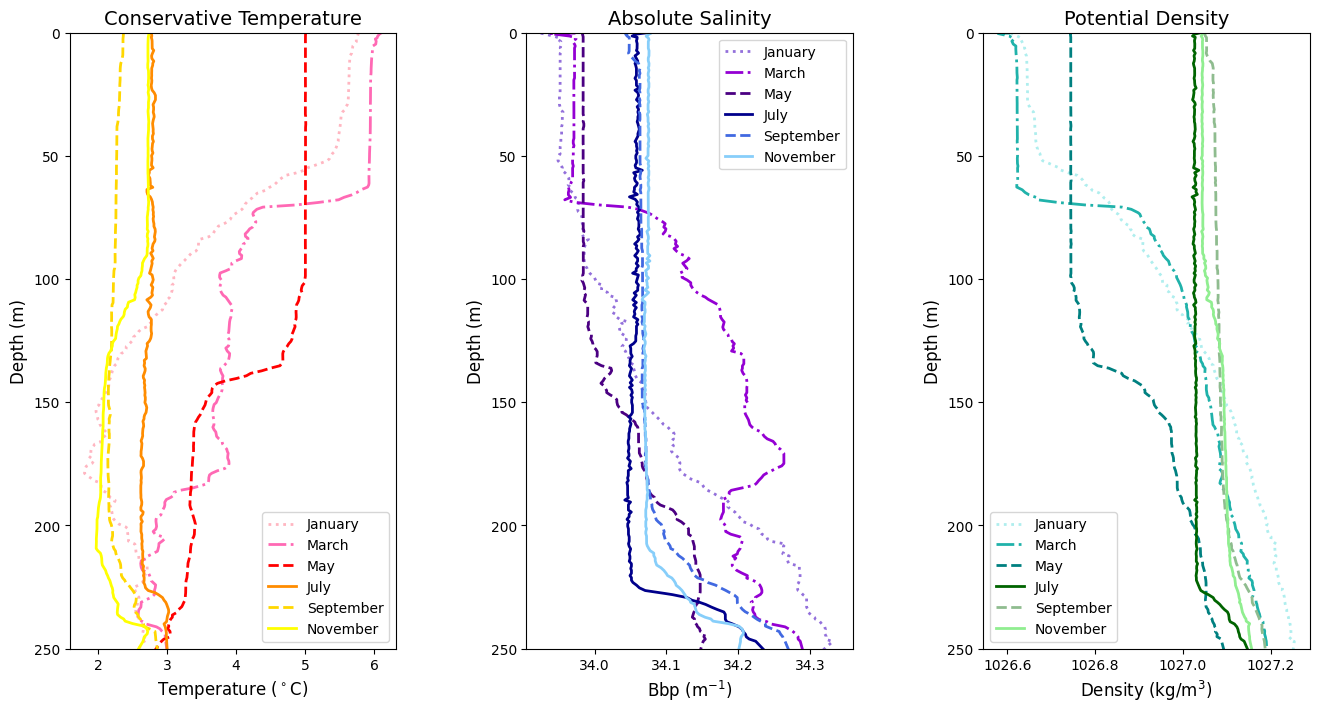

In [77]:
fig = plt.figure(figsize=(16,8))
# float 6901004, 5905373
# plot 1: conservative temperature
ax = fig.add_subplot(131)

x11 = cons_temp_1.iloc[0:548]
x21 = cons_temp_2.iloc[0:548]
x31 = cons_temp_3.iloc[0:548]
x41 = cons_temp_4.iloc[0:548]
x51 = cons_temp_5.iloc[0:548]
x61 = cons_temp_6.iloc[0:548]
y11 = depth_1_pos.iloc[0:548]
y21 = depth_2_pos.iloc[0:548]
y31 = depth_3_pos.iloc[0:548]
y41 = depth_4_pos.iloc[0:548]
y51 = depth_5_pos.iloc[0:548]
y61 = depth_6_pos.iloc[0:548]

ax.set_ylim (0, 250)
ax.invert_yaxis()

ax.plot(x11, y11, label = 'January', lw=2, c='lightpink', ls =':')
ax.plot(x21, y21, label = 'March', lw=2, c='hotpink', ls ='-.')
ax.plot(x31, y31, label = 'May', lw=2, c='red', ls ='--')
ax.plot(x41, y41, label = 'July', lw=2, c='darkorange')
ax.plot(x51, y51, label = 'September', lw=2, c='gold', ls = '--')
ax.plot(x61, y61, label = 'November', lw=2, c='yellow')

# adding line for average mixed layer depth
# plt.axhline(y=68.67, color='black', linestyle='--', linewidth=1, label = 'Avg Mixed Layer Depth')

# current_yticks = list(ax.get_yticks())
# new_tick_location = 68.67
# new_tick_label = 'Special Value'
# updated_yticks = current_yticks + [new_tick_location]
# ax.set_yticks(updated_yticks)

ax.set_xlabel(r'Temperature ($^\circ$C)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_title('Conservative Temperature', fontsize=14)
ax.legend()

ax = fig.add_subplot(132)

x12 = abs_sal_1.iloc[0:548]
x22 = abs_sal_2.iloc[0:548]
x32 = abs_sal_3.iloc[0:548]
x42 = abs_sal_4.iloc[0:548]
x52 = abs_sal_5.iloc[0:548]
x62 = abs_sal_6.iloc[0:548]
y12 = depth_1_pos.iloc[0:548]
y22 = depth_2_pos.iloc[0:548]
y32 = depth_3_pos.iloc[0:548]
y42 = depth_4_pos.iloc[0:548]
y52 = depth_5_pos.iloc[0:548]
y62 = depth_6_pos.iloc[0:548]

# ax.set_xlim (34, 34.3)
ax.set_ylim (0, 250)
ax.invert_yaxis()

ax.plot(x12, y12, label = 'January', lw=2, c='mediumpurple', ls =':')
ax.plot(x22, y22, label = 'March', lw=2, c='darkviolet', ls ='-.')
ax.plot(x32, y32, label = 'May', lw=2, c='indigo', ls ='--')
ax.plot(x42, y42, label = 'July', lw=2, c='darkblue')
ax.plot(x52, y52, label = 'September', lw=2, c='royalblue', ls = '--')
ax.plot(x62, y62, label = 'November', lw=2, c='lightskyblue')

# adding line for average mixed layer depth
# plt.axhline(y=68.67, color='black', linestyle='--', linewidth=1, label = 'Avg Mixed Layer Depth')

# current_yticks = list(ax.get_yticks())
# new_tick_location = 68.67
# new_tick_label = 'Special Value'
# updated_yticks = current_yticks + [new_tick_location]
# ax.set_yticks(updated_yticks)

ax.set_xlabel(r'Bbp (m$^{-1}$)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_title('Absolute Salinity', fontsize=14)
ax.legend()


ax = fig.add_subplot(133)

ax.set_ylim (0, 250)
ax.invert_yaxis()

x13 = p_density_1.iloc[0:548]
x23 = p_density_2.iloc[0:548]
x33 = p_density_3.iloc[0:548]
x43 = p_density_4.iloc[0:548]
x53 = p_density_5.iloc[0:548]
x63 = p_density_6.iloc[0:548]
y13 = depth_1_pos.iloc[0:548]
y23 = depth_2_pos.iloc[0:548]
y33 = depth_3_pos.iloc[0:548]
y43 = depth_4_pos.iloc[0:548]
y53 = depth_5_pos.iloc[0:548]
y63 = depth_6_pos.iloc[0:548]

ax.plot(x13, y13, label = 'January', lw=2, c='paleturquoise', ls =':')
ax.plot(x23, y23, label = 'March', lw=2, c='lightseagreen', ls ='-.')
ax.plot(x33, y33, label = 'May', lw=2, c='teal', ls ='--')
ax.plot(x43, y43, label = 'July', lw=2, c='darkgreen')
ax.plot(x53, y53, label = 'September', lw=2, c='darkseagreen', ls = '--')
ax.plot(x63, y63, label = 'November', lw=2, c='lightgreen')

# # adding line for average mixed layer depth
# plt.axhline(y=68.67, color='black', linestyle='--', linewidth=1, label = 'Avg Mixed Layer Depth')

# current_yticks = list(ax.get_yticks())
# new_tick_location = 68.67
# new_tick_label = 'Special Value'
# updated_yticks = current_yticks + [new_tick_location]

ax.set_xlabel(r'Density ($\mathregular{kg/m^3}$)', fontsize=12)
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_title('Potential Density', fontsize=14)
ax.legend()

plt.subplots_adjust(hspace=0.5, wspace=0.4)

In [129]:
df_test = pd.read_csv('profile_5904483.csv')

# Specify the cycles you want to include in a list: January (2017-01-22, cycle 230)
target_cycles_test = [128]

# Create a mask using isin()
mask_multiple_test = df_test['CYCLE_NUMBER'].isin(target_cycles_test)

# Apply the mask
multiple_cycles_subset_test = df_test[mask_multiple_test]

In [130]:
multiple_cycles_subset_test['DATE']

87940    2017-10-04 12:13:32.001306
87941    2017-10-04 12:13:32.001306
87942    2017-10-04 12:13:32.001306
87943    2017-10-04 12:13:32.001306
87944    2017-10-04 12:13:32.001306
                    ...            
88637    2017-10-04 12:13:32.001306
88638    2017-10-04 12:13:32.001306
88639    2017-10-04 12:13:32.001306
88640    2017-10-04 12:13:32.001306
88641    2017-10-04 12:13:32.001306
Name: DATE, Length: 702, dtype: object

Starting select_profiles...
Validating parameters...
Validating longitude and latitude limits...
Validating start and end dates...
Validating 'type' keyword argument...
Preparing float data for filtering...
Validating passed floats...
Filtering through 1 floats
There are 261 profiles associated with these floats

Applying outside=None constraints...
1 floats selected
261 profiles selected according to time and space constraints
Floats Selected: dict_keys([5904483])

Validating passed floats...


/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/oneargopy/OneArgo.py:769: UserWarning: no explicit representation of timezones available for np.datetime64
  self.start_date = np.datetime64(self.start_date)
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/oneargopy/OneArgo.py:770: UserWarning: no explicit representation of timezones available for np.datetime64
  self.end_date = np.datetime64(self.end_date)
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/oneargopy/OneArgo.py:1074: UserWarning: no explicit representation of timezones available for np.datetime64
  beginning_of_full_range = np.datetime64(datetime(1995, 1, 1, tzinfo=timezone.utc))
/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/oneargopy/OneArgo.py:1075: UserWarning: no explicit representation of timezones available for np.datetime64
  end_of_full_range = np.datetime64(datetime.now(timezone.utc))


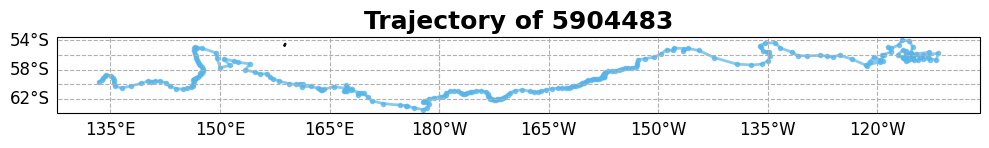

In [106]:
argo.trajectories(argo.select_profiles(floats = 5904483))